In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

1. Abordando e analisando o problema

In [ ]:
## Objetivo:
## Prever se um cliente será aprovado para crédito.

## Tipo de problema:
## Classificação binária (0 = não aprovado, 1 = aprovado).

## Possíveis desafios:
## - Variáveis categóricas (credit_history, employment_type, housing);
## - Escalas diferentes nas variáveis numéricas;
## - Possível desbalanceamento de classes.

2. Obtendo os dados

In [ ]:
df = pd.read_csv("credit_approval_dataset.csv")
df.head()

,age,income,credit_score,loan_amount,employment_years,debt_ratio,credit_history,employment_type,housing,approved
0,56,1787,822,30940,39,0.331395,good,self-employed,rent,1
1,69,5406,610,8866,31,0.395483,good,informal,rent,1
2,46,3487,672,10603,19,0.630994,bad,formal,mortgage,0
3,32,2155,743,21876,27,0.194591,good,self-employed,rent,1
4,60,3706,508,11902,32,0.863156,good,formal,own,0


3. Explorando os dados


In [ ]:
df.info()
df.describe()

## Checando a distribuição da variável alvo
df['approved'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1000 non-null   int64  
 1   income            1000 non-null   int64  
 2   credit_score      1000 non-null   int64  
 3   loan_amount       1000 non-null   int64  
 4   employment_years  1000 non-null   int64  
 5   debt_ratio        1000 non-null   float64
 6   credit_history    1000 non-null   object 
 7   employment_type   1000 non-null   object 
 8   housing           1000 non-null   object 
 9   approved          1000 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


,count
approved,
0,505
1,495


4. Tratando os dados


In [ ]:
## Verificando valores nulos valores nulos
df.isnull().sum()

df = df.dropna()

5. Separando a base de dados em arrays

In [ ]:
X = df.drop("approved", axis=1)
y = df["approved"]

6. Aplicando as técnicas de pré-processamento

In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

7. Dividindo a base entre treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8. Definindo os modelos e aplicando o treinamento

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    results[name] = pipeline

9. Validando o modelo

In [ ]:
metrics = {}

## Avaliando os modelos
for name, model in results.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    metrics[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.875
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       105
           1       0.90      0.83      0.86        95

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.87       200


Random Forest
Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       105
           1       1.00      0.98      0.99        95

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


Gradient Boosting
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        95

    accuracy                           1.00       200
   macro avg       1.00     

9.1 Comparando os modelos através de um gráfico

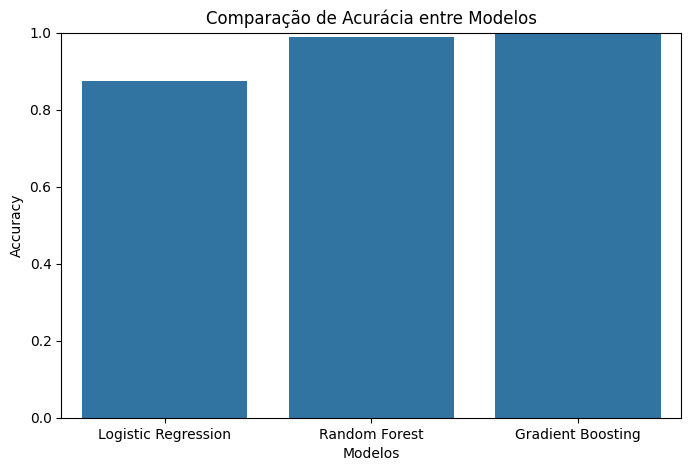

In [ ]:
## Transformando em DataFrame
metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Accuracy'])

## Plotando o gráfico
plt.figure(figsize=(8,5))
sns.barplot(x=metrics_df.index, y='Accuracy', data=metrics_df)
plt.title("Comparação de Acurácia entre Modelos")
plt.ylabel("Accuracy")
plt.xlabel("Modelos")
plt.ylim(0,1)
plt.show()

Através das métricas expostas no gráfico, é possível ver que, dentre os modelos selecionados:

Logistic Regression teve 87,5% de acurácia

Random Forest teve 99% de acurácia

Gradient Boosting teve 100% de acurácia


Como o objetivo era um algoritmo que alcançasse uma acurácia de 85%, Logistic Regression é o modelo mais indicado para o caso.

10. Salvando os modelos

In [ ]:
## Criando pasta para salvar
os.makedirs("modelos", exist_ok=True)

## Salvando todos os modelos
for name, model in results.items():
    filename = f"modelos/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"Modelo salvo em: {filename}")